In [ ]:
include("CRD_STA.jl")
include("Fun.jl")
using LinearAlgebra
using NonlinearEigenproblems
using SparseArrays
using DelimitedFiles
using Plots

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0,L1,L2 = assemble_mat(cof,D,D2,be,omega)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return cof,eigval,eigvec
end

In [ ]:
function integral(x,y)
    inte_progress =  zeros(ComplexF64,length(x),1)
    for i = 1 : length(x)
        inte_progress[i] = x[1:i,1]' * y[1:i,1]
    end
    return inte_progress
end

In [ ]:
function mat_diff(A,B,N_cheb)
    block_size = N_cheb + 1
    nblock = 5
    C = zeros(ComplexF64,block_size*nblock,block_size*nblock)
    for i = 0 : nblock - 1
        for j = 0 : nblock - 1
        C[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)] = (B * A[1+block_size*i:block_size*(i+1),1+block_size*j:block_size*(j+1)])
        end
    end

    return C'
end

In [ ]:
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,5N-8,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,3N-4,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,2N-2,0im)
    insert!(eigvec,N,0im)
    insert!(eigvec,N,0im)
    rho = eigvec[1:N]
    u = eigvec[N+1:2N]
    v = eigvec[2N+1:3N]
    w = eigvec[3N+1:4N]
    T = eigvec[4N+1:5N]
    return eigvec,(rho,u,v,w,T)
end

In [57]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
n = 10
num = 1
R = 450
omega = 7.9/R
be = n/R
Ma = Mr/R
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)


┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:690
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

([0.0; 0.0002824811174422547; … ; -2.818243270631624e-24; -2.818243270631624e-24;;], [0.0; -0.00034117928292027233; … ; -1.0; -1.0;;], [-5.164111581970036e-25; -1.5650555167311376e-7; … ; -0.8844732494695119; -0.8844732494695119;;], [1.0; 1.0000046577924722; … ; 0.9999998130454335; 0.9999998130454335;;], [1.0; 0.9999953422292228; … ; 1.0000001869546014; 1.0000001869546014;;], [0.0; 0.0005539326468201291; … ; 20.0; 20.0;;], [-0.6666666666666666; -0.6666697718616481; … ; -0.666666542030289; -0.666666542030289;;], [1.3888888888888888; 1.3888953580451002; … ; 1.3888886292297686; 1.3888886292297686;;], [-2970.151515151124 3611.390030573762 … -0.9093198110834142 0.45454545454545453; -902.4262223900014 451.0994992567002 … 0.45456220808173375 -0.2272238764335357; … ; 4.436834640202506e-8 -8.875904163768224e-8 … -8.80829037817145e-5 0.00017621017590984625; -0.0 0.0 … -0.0 0.0], [5.295001504873778e6 -8.41357312149442e6 … 5384.226905905448 -2691.424943501555; 2.444105391034474e6 -3.49456168423214

In [58]:
cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw)
nep = PEP([L0,L1,L2]); 
eigval,eigvec = iar(nep, σ = 0.2, neigs = 2,maxit = 500,tol=1e-12)
vel_full,vel = eig_full(eigvec,N_cheb,1)
# res = (L0 +  (eigval[1])*L1 + (eigval[1])^2*L2) * eigvec[:,1];
# plot(abs.(res))

(ComplexF64[-1.1773683054114366e-9 - 1.5639905207204296e-9im, 6.8660865177005e-9 + 6.034760314130804e-8im, 3.101005412065947e-8 + 2.461877382794282e-7im, 7.130524962527416e-8 + 5.562715971641104e-7im, 1.278485523958149e-7 + 9.911154812380343e-7im, 2.0079975361981477e-7 + 1.5514199332915626e-6im, 2.903703555316283e-7 + 2.238032374684369e-6im, 3.96784439324357e-7 + 3.051883887137752e-6im, 5.201628059295401e-7 + 3.993884595801544e-6im, 6.603244240756425e-7 + 5.0647684552516795e-6im  …  -3.109563271141264e-12 - 7.751149657016232e-12im, 1.69193189748898e-12 + 3.773232594428411e-12im, -8.867546318546901e-13 - 2.3061584109376754e-12im, 5.163345404989202e-13 + 1.2309013400560453e-12im, -2.9260410283962757e-13 - 5.517729827729523e-13im, 2.4831547408565857e-13 + 1.9359600728074966e-13im, 1.001419130385514e-13 - 4.640963152725253e-14im, -9.676863619743632e-15 + 8.137787532486403e-14im, -7.189148660590105e-14 - 7.30392868564367e-14im, 0.0 + 0.0im], (ComplexF64[-1.1773683054114366e-9 - 1.5639905207

In [64]:
A0_raw = cof.D1' + im * be * cof.B' - im * omega * cof.Ta' - be^2 * cof.Vyy' - cof.dC' - im *be*cof.dVyz' + cof.d2Vzz' - (cof.C' + im * be * cof.dVyz' - 2 * cof.dVzz') * kron(I(5),D) + cof.Vzz' * kron(I(5),D2)
A1_raw = im * cof.A' - be * cof.Vxy' + im * cof.dVxz' - im * cof.Vxz' * kron(I(5),D) 
A2_raw = -cof.Vxx'
A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw)
nep = PEP([A0,A1,A2]); 
eigval_A,eigvec_A = iar(nep,σ = 0.2, neigs = 1 ,maxit = 500,tol=1e-15)
vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
@show eigval,eigval_A 

(eigval, eigval_A) = (ComplexF64[0.19051067035585217 - 0.011784130268114559im, 0.2169724012839551 + 0.005573551434864075im], ComplexF64[0.18969546778889146 - 0.011349215411445837im])


(ComplexF64[0.19051067035585217 - 0.011784130268114559im, 0.2169724012839551 + 0.005573551434864075im], ComplexF64[0.18969546778889146 - 0.011349215411445837im])

In [62]:
Q = abs.(eigvec_A[:,1]' * (L1 + (eigval[2]+eigval_A[1]) * L2) * eigvec[:,2])

14.200112784536797

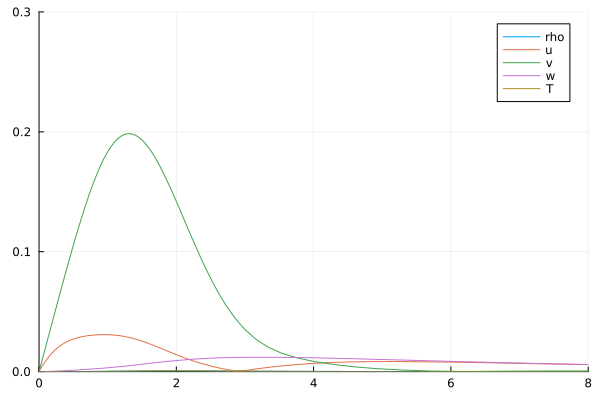

In [55]:
plot(z,abs.(vel[1]),label = "rho",xlims=[0,8],ylims=[0,0.3001]) 
plot!(z,abs.(vel[2]),label = "u")
plot!(z,abs.(vel[3]),label = "v")
plot!(z,abs.(vel[4]),label = "w")
plot!(z,abs.(vel[5]),label = "T") 

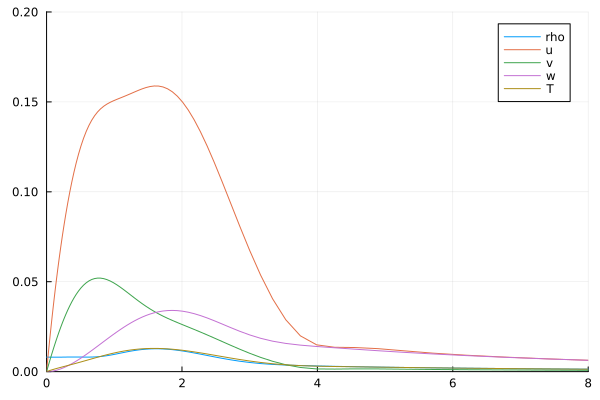

In [56]:
plot(z,abs.(vel_A[1]),label = "rho",xlims=[0,8],ylims=[0,0.2001]) 
plot!(z,abs.(vel_A[2]),label = "u")
plot!(z,abs.(vel_A[3]),label = "v")
plot!(z,abs.(vel_A[4]),label = "w")
plot!(z,abs.(vel_A[5]),label = "T") 

In [ ]:
N_cheb = 99
Ro = -1
Tw = 1
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
n = 32
num = 1
R = 100
omega = 0/R
be = n/R
Ma = Mr/R
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)

In [ ]:
coff = [0 0 0 0 0]
for R = 300 : 2 : 340
    be = 32/R
    Ma = Mr/R
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    L0_raw,L1_raw,L2_raw = assemble_mat(cof,D,D2,be,omega)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep, σ = 0.5, neigs = 1,maxit = 500,tol=5e-13)
    vel_full,vel = eig_full(eigvec,N_cheb,1)
    A0_raw = cof.D1' + im * be * cof.B' - im * omega * cof.Ta' - be^2 * cof.Vyy' - cof.dC' - im *be*cof.dVyz' + cof.d2Vzz' - (tr(cof.C,N_cheb)+ im * be * cof.dVyz' - 2 * cof.dVzz') * kron(I(5),D)+ tr(cof.Vzz,N_cheb) * kron(I(5),D2)
    A1_raw = im * tr(cof.A,N_cheb) - be * tr(cof.Vxy,N_cheb) + im * cof.dVxz' - im * tr(cof.Vxz,N_cheb) * kron(I(5),D) 
    A2_raw = -tr(cof.Vxx,N_cheb)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw)
    nep = PEP([A0,A1,A2]); 
    eigval_A,eigvec_A = iar(nep,σ = 0.5, neigs = 1 ,maxit = 500,tol=1e-14)
    vel_full_A,vel_A = eig_full(eigvec_A,N_cheb,1)
    Q = abs(eigvec_A[:,1]' * (L1 + (eigval[1]+eigval_A[1]) * L2) * eigvec[:,1])    
    x0 = R
    u_wall = -(D*F)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    v_wall = -(D*G)[1] * exp(-eigval[1] * (im* x0 + 2 * eigval[1]))
    w_wall = 0

    BC = rho[1,1] * vel_A[1][1] * v_wall + (Tw/R) * abs.(D*vel_A[2])[1] * u_wall + (3Tw/4R) * abs.(D*vel_A[3])[1] * v_wall
    Cr = abs(-im * BC/Q)
    # @show Cr,(D*vel_A[2])[1],(D*vel_A[3])[1]
    coff = [coff;[R Cr eigval eigval_A vel_A[1][1]]]
    writedlm("Cr_lof.dat",coff[2:end,:])
end

In [ ]:
vel[5][1]

In [ ]:
plot(real(coff[2:end,1]),real(coff[2:end,2])./real(coff[2,2]))
plot!(real(coff[2:end,1]),abs.(coff[2:end,5])./abs.(coff[2,5]))

In [ ]:
@show Cr,(D*vel_A[2])[1],(D*vel_A[3])[1]
